<a href="https://colab.research.google.com/github/byuruth/Econ484/blob/main/examples/Basic%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Some Basics: Regression and Prediction

Load useful packages

In [5]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Read in data

In [6]:
# On your own (can look at last week's code)

In [7]:
#@title Cheat
housedata=pd.read_csv('https://github.com/brighamfrandsen/econ484/blob/master/data/housingprices.csv?raw=true')
print(housedata.head())
print("Shape: {}".format(str(housedata.shape)))

   price  crime   nox  rooms  dist  radial  proptax  stratio  lowstat  \
0  24000  0.006  5.38   6.57  4.09       1     29.6     15.3     4.98   
1  21599  0.027  4.69   6.42  4.97       2     24.2     17.8     9.14   
2  34700  0.027  4.69   7.18  4.97       2     24.2     17.8     4.03   
3  33400  0.032  4.58   7.00  6.06       3     22.2     18.7     2.94   
4  36199  0.069  4.58   7.15  6.06       3     22.2     18.7     5.33   

      lprice      lnox  lproptax  
0  10.085810  1.682688  5.690360  
1   9.980402  1.545433  5.488938  
2  10.454500  1.545433  5.488938  
3  10.416310  1.521699  5.402678  
4  10.496790  1.521699  5.402678  
Shape: (506, 12)


# Define matrix of regressors

In [8]:
# On your own, define x matrix with crime, nox, rooms, dist, radial proptax

In [9]:
#@title Cheat
x=housedata[['crime','nox','rooms','dist','radial','proptax']]
print(x.head())

   crime   nox  rooms  dist  radial  proptax
0  0.006  5.38   6.57  4.09       1     29.6
1  0.027  4.69   6.42  4.97       2     24.2
2  0.027  4.69   7.18  4.97       2     24.2
3  0.032  4.58   7.00  6.06       3     22.2
4  0.069  4.58   7.15  6.06       3     22.2


# Define outcome vector

In [10]:
# On your own

In [11]:
#@title Cheat
y=housedata['price']

Visualize the data

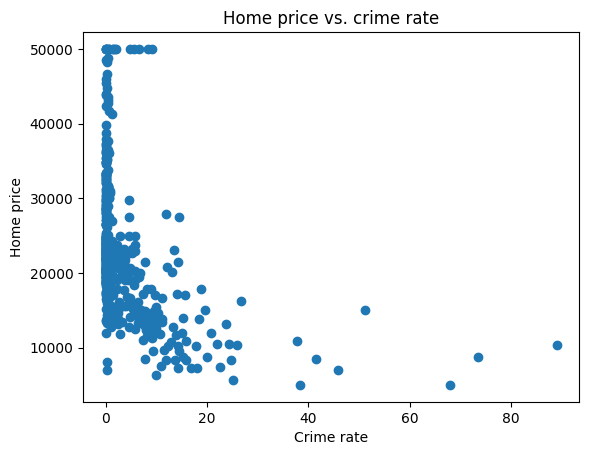

In [12]:
plt.scatter(housedata['crime'], y)
plt.xlabel("Crime rate")
plt.ylabel("Home price")
plt.title("Home price vs. crime rate")

plt.show()

In [13]:
# Now try same, but with other x-variables

# *Fit*  (estimate) the model and look at coefficients:

In [14]:
# On your own

In [15]:
#@title Cheat
lm = linear_model.LinearRegression()
model = lm.fit(x,y)
lm.coef_

array([ -174.77688471, -1756.79773187,  7563.74833977,  -795.50379048,
         163.72511566,  -160.76549024])

# Interpret

Would you say this is causal or descriptive? Now let's do prediction. First in-sample (easy):

In [16]:
yhat_insample = lm.predict(x)
print(yhat_insample)

[25773.34847057 26179.12176735 31927.57050557 30376.62663501
 31504.72214124 26065.63963511 21013.6310335  21903.62200715
 17704.24713652 20104.29294136 23159.82549153 20475.57496422
 20192.43798837 20795.88468148 22127.92466499 20055.81500736
 20737.56011157 21429.49568054 17783.32004328 19838.98991514
 18536.85753942 21389.57434981 22708.49894849 20159.64710138
 20794.60518017 18318.52582541 19753.48439847 21702.11323657
 25062.14667597 26558.60830443 19123.58871333 22006.3932877
 21236.16653202 19545.57754996 22514.36985574 23116.48315234
 22414.06808876 22055.14969443 23009.83599439 27845.96427381
 31097.3273986  28889.66973551 24348.97385526 24648.37780492
 23595.74500521 21130.70621233 21959.74732266 23298.53383555
 18385.81227709 19729.49352522 22063.64739158 23206.24937924
 26229.82616942 22373.01362367 17854.03248818 31400.13726166
 22415.67018035 27827.00184979 22368.06807496 21488.63788035
 20178.72160348 21866.63362585 25257.54992509 26927.07537712
 29455.62115522 23937.139

Now out-of-sample for a hypothetical house not in our dataset:

In [17]:
newX=np.array([[.01,4,8,5,2,25]])
yhat_outsample=lm.predict(newX)
print(yhat_outsample)

[39192.52828031]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


What about standard errors on the coefficients? Have to use statsmodels for that!

In [18]:
rhs = sm.add_constant(x)
model = sm.OLS(y, rhs)
results = model.fit(cov_type='HC3')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     103.2
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           3.84e-84
Time:                        19:44:27   Log-Likelihood:                -5109.4
No. Observations:                 506   AIC:                         1.023e+04
Df Residuals:                     499   BIC:                         1.026e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6619.3138   6053.896     -1.093      0.2

Now, on your own, include $rooms_i^2$ in the model to see if there is nonlinearity. What is the coefficient and standard error on the squared term? What is the improvement in $R^2$?